In [46]:
import sympy as sp
import numpy as np
from tqdm import tqdm
from scipy.optimize import fsolve
import csv
import os
import matplotlib.pyplot as plt
from scipy.optimize import newton
from operator import itemgetter

Dg = 0.02 # m

v = 0.4e-3 # m

Dg = 0.02 # m

v = 0.4e-3 # m

Q_regi=(3.85e-3)  *10 #  #megtartjuk a korábbi bevitt hőmennyiséget

t_heating = 10#/5 #s #2025.10.24 lefuttatom -------------Rövidebb gerjesztési idő mellett

P_heating = Q_regi/t_heating #3.85e-3 # W EZ LESZ ÁTÍRVA *1e3 ; *1e6 ... # 2025.09.27. futtatva 3.85 W-tal
                                                                # 2025.10.17. újra lefuttatom 3.85e-3 al mert korábban nem voltak jól kinyert adatok


Lh = 0.1 # m

print(str(P_heating) + " W")

R_belso = Dg / 2 -v

V_gomb = 4/3 * np.pi *R_belso**3

print("A gömb belső sugara: "+str(R_belso) + " m")
print(str(V_gomb) + " m3")

Rh = np.sqrt(V_gomb / np.pi / Lh) #henger sugara

A_km = Rh**2 * np.pi

print("henger sugara: " + str(Rh) + " m")
print(str(A_km) + " m2")

A_check = V_gomb / Lh 
print(str(A_check) + " m2")

Q_total = P_heating * t_heating

print(str(Q_total) + " J")

#a henger x=0 végét melegítjük csak

q0 = P_heating / A_km

print(str(q0) + " W/m2")

0.00385 W
A gömb belső sugara: 0.009600000000000001 m
3.705973490621893e-06 m3
henger sugara: 0.0034346004134396774 m
3.7059734906218934e-05 m2
3.705973490621893e-05 m2
0.0385 J
103.88633404266305 W/m2


In [47]:
# Critical properties for CO2
Tc = 304.1282  # K
Pc = 7.3773e6  # Pa
Rhoc = 467.6 # kg/m3
R_universal = 8.314462618  # J/(mol·K)
M = 0.04401  # kg/mol

# Specific gas constant for CO2
R = R_universal / M  # J/(kg·K) = 188.9 J/(kg·K)

#Tr = T_proba / Tc
#Delta = Rho_proba / Rhoc

Lk = [0.0151874307, 0.0280674040, 0.0228564190, -0.00741624210]

B1 = [0.0100128, 0.0560488, -0.0811620, 0.0624337, -0.0206336, 0.00253248]

B2 = [0.00430829, -0.0358563, 0.0671460, -0.0522855, 0.0174571, -0.00196414]


In [48]:
a0i = [8.37304456, -3.70454304, 2.5, 1.99427042, 0.62105248, 0.41195293, 1.04028922, 0.08327678]

Theta0i = [0, 0, 0, 3.15163, 6.11190, 6.77708, 11.32384, 27.08792]

#span wagner table 27
ni = [0.38856823203161, 2.9385475942741, -5.5867188534934, -0.76753199592477, 0.31729005580416, 0.54803315897767, 0.12279411220335 , 2.1658961543220, 1.5841735109724, -0.23132705405503, 0.058116916431436, -0.55369137205382, 0.48946615909422, -0.024275739843501, 0.062494790501678, -0.12175860225246, -0.37055685270086, -0.016775879700426, -0.11960736637987, -0.045619362508778, 0.035612789270346, -0.007442772713252, -0.0017395704902432, -0.021810121289527, 0.024332166559236, -0.037440133423463, 0.14338715756878, -0.13491969083286, -0.023151225053480, 0.012363125492901, 0.0021058321972940, -0.00033958519026368, 0.0055993651771592, -0.00030335118055646 , -213.65488688320, 26641.569149272, -24027.212204557, -283.41603423999, 212.47284400179 , -0.66642276540751, 0.72608632349897, 0.055068612842]
di = [1, 1, 1, 1, 2, 2, 3 , 1, 2, 4, 5, 5, 5, 6, 6, 6, 1, 1, 4, 4, 4, 7, 8, 2, 3, 3, 5, 5, 6, 7, 8, 10, 4, 8 , 2, 2, 2, 3, 3 , 0, 0, 0]
ti = [0, 0.75, 1, 2, 0.75, 2, 0.75 , 1.5, 1.5, 2.5, 0, 1.5, 2, 0, 1, 2, 3, 6, 3, 6, 8, 6, 0, 7, 12, 16, 22, 24, 16, 24, 8, 2, 28, 14 , 1, 0, 1, 3, 3, 0, 0, 0]

ai = [0] * 39
ai_append = [3.5, 3.5, 3]
ai.extend(ai_append)

bi = [0] * 39
bi_append = [0.875, 0.925, 0.875]
bi.extend(bi_append)

ci = [0] * 7
ci_append = [1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 6, 0, 0, 0, 0 , 0, 0, 0, 0 ]
ci.extend(ci_append)

Betai = [0] * 34
Betai_append = [325, 300, 300, 275, 275, 0.3, 0.3, 0.3]
Betai.extend(Betai_append)

Alphai = [0] * 34
Alphai_append = [25, 25, 25, 15, 20, 0, 0, 0]
Alphai.extend(Alphai_append)

Ai = [0] * 39
Ai_append = [0.7, 0.7, 0.7]
Ai.extend(Ai_append)

Bi = [0] * 39
Bi_append = [0.3, 0.3, 1]
Bi.extend(Bi_append)

Ci = [0] * 39
Ci_append = [10, 10, 12.5]
Ci.extend(Ci_append)

Di = [0] * 39
Di_append = [275, 275, 275]
Di.extend(Di_append)

Gammai = [0] * 34
Gammai_append = [1.16, 1.19, 1.19, 1.25, 1.22, 0, 0, 0]
Gammai.extend(Gammai_append)

Epsiloni = [0] * 34
Epsiloni_append = [1,1,1,1,1, 0, 0, 0]
Epsiloni.extend(Epsiloni_append)


In [49]:
a_bin = [ -7.0602087, 1.9391218, -1.6463597, -3.2995634 ]

t_bin = [ 1, 1.5, 2, 4 ]

In [50]:
def vapor_pressure(T):
    vapor_sum = 0
    for i in range(len(a_bin)):
        vapor_sum += Tc / T * (a_bin[i] * (1 - T/Tc)**t_bin[i] )
    vapor_p = Pc * np.exp(vapor_sum)
    return vapor_p

In [51]:
T_vapor = np.linspace(0,Tc, 1000)

p_vapor = np.zeros(len(T_vapor))

for i in range(len(T_vapor)):
    p_vapor[i] = vapor_pressure(T_vapor[i])

#print(p_vapor)


#triple point

Tt = 216.592 #K

pt = 518500 #/ 1e6 #MPa


C:\Users\krist\AppData\Local\Temp\ipykernel_12768\3938205893.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  vapor_sum += Tc / T * (a_bin[i] * (1 - T/Tc)**t_bin[i] )
C:\Users\krist\AppData\Local\Temp\ipykernel_12768\3938205893.py:4: RuntimeWarning: invalid value encountered in scalar add
  vapor_sum += Tc / T * (a_bin[i] * (1 - T/Tc)**t_bin[i] )


In [52]:

def density_from_pressure(Rho0, T0, p0):

    Delta = Rho0 / Rhoc
    Tau = Tc / T0

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    p_guess = Rho0*R*T0*(1+Delta*dFirdDelta)
    
    return p_guess - p0



In [53]:
def thermal_conductivity(T0, Rho0):

    #Lambda0 meghatározása
    Tr = T0 / Tc
    Delta = Rho0 / Rhoc

    Lambda0_sum = 0
    i = 0
    for i in range(0,4):
        Lambda0_sum += Lk[i] / Tr**i
        #print(i)
        #print(Lk[i])

    Lambda0 = np.sqrt(Tr) / (Lambda0_sum) * 0.001
    #print(Lambda0)

    Lambda_res = 0
    i = 0
    #range 0-6, kitevobe i+1 ??
    for i in range(0,6):
        Lambda_res += (B1[i] + B2[i] * Tr) * Delta**(i +1)
        #print(B1[i])
        #print(i+1)
    #print(Lambda_res)

    Lamdba_c = 0.001*(-17.47-44.88*(T0/Tc -1)) / (0.8563-np.exp(8.865*(T0/Tc -1) + 4.16*(Rho0/Rhoc -1)**2 + 2.303*(T0/Tc -1)*(Rho0/Rhoc -1)- (Rho0/Rhoc -1)**3) - 0.4503*(Rho0/Rhoc -1) - 7.197*(T0/Tc -1))
    #print(Lamdba_c)

    Lambda = Lambda0 + Lambda_res + Lamdba_c

    return Lambda

    #print('Lambda : ' + str(Lambda))


In [54]:
def get_cp(T0, Rho0):

    #Lambda0 meghatározása
    Tau =   Tc / T0
    Delta = Rho0 / Rhoc

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    d2FirdDelta2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdDelta2_term1 += ni[i]*di[i]*(di[i]-1)*Delta**(di[i]-2)*Tau**ti[i]

    d2FirdDelta2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdDelta2_term2 += ni[i]*np.exp(-Delta**ci[i])*(Delta**(di[i]-2)*Tau**ti[i]*((di[i]-ci[i]*Delta**ci[i])*(di[i]-1-ci[i]*Delta**ci[i])-ci[i]**2*Delta**ci[i]))

    d2FirdDelta2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdDelta2_term3 += ni[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (-2*Alphai[i]*Delta**di[i] + 4*Alphai[i]**2*Delta**di[i]*(Delta-Epsiloni[i])**2-4*di[i]*Alphai[i]*Delta**(di[i]-1)*(Delta-Epsiloni[i]) + di[i]*(di[i]-1)*Delta**(di[i]-2) )

    d2PsidDelta2 = [0] * 42
    i=0
    for i in range(39, 42):
        d2PsidDelta2[i] = (2 * Ci[i] * (Delta -1)**2 -1)*2*Ci[i]*Psi[i]

    d2LapldDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2LapldDelta2[i] = 1/ ( Delta - 1) * dLapldDelta[i] + (Delta-1)**2 * (4*Bi[i]*ai[i]*(ai[i]-1)*((Delta-1)**2)**(ai[i]-2) + 2* Ai[i]**2*(1 / Betai[i])**2* ( ( (Delta-1)**2 )**(1/(2*Betai[i])-1) )**2 + Ai[i]*Theta[i]*4/Betai[i]* (1/(2*Betai[i]-1)) * ( (Delta-1)**2 )**(1/(2*Betai[i])-2) )

    d2Lapl_bidDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2Lapl_bidDelta2[i] = bi[i]*(Lapl[i]**(bi[i]-1)*d2LapldDelta2[i] + (bi[i]-1)*Lapl[i]**(bi[i]-2) * dLapldDelta[i]**2)

    d2FirdDelta2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdDelta2_term4 += ni[i] * (Lapl[i]**bi[i]* ( 2*dPsidDelta[i] + Delta * d2PsidDelta2[i]) + 2* dLapl_bi_dDelta[i]*(Psi[i] + Delta * dPsidDelta[i]) + d2Lapl_bidDelta2[i]*Delta*Psi[i] )

    d2FirdDelta2 = d2FirdDelta2_term1 + d2FirdDelta2_term2 + d2FirdDelta2_term3 + d2FirdDelta2_term4
    #print("d2FirdDelta2: "+str(d2FirdDelta2))

    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))

    d2FirdDeltaTau_term1 = 0
    i=0
    for i in range(0,7):
        d2FirdDeltaTau_term1 += ni[i]*di[i]*ti[i]*Delta**(di[i]-1)*Tau**(ti[i]-1)

    d2FirdDeltaTau_term2 = 0
    i=0
    for i in range(7,34):
        d2FirdDeltaTau_term2 += ni[i]*np.exp(-Delta**ci[i])*Delta**(di[i]-1)*ti[i]*Tau**(ti[i]-1)*(di[i]-ci[i]*Delta**ci[i])

    d2FirdDeltaTau_term3 = 0
    i=0
    for i in range(34,39):
        d2FirdDeltaTau_term3 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (di[i]/ Delta - 2*Alphai[i]*(Delta-Epsiloni[i])) * (ti[i]/ Tau -2*Betai[i]*(Tau-Gammai[i]))

    d2Lapl_bidDeltaTau = [0]*42
    i=0
    for i in range(39, 42):
        d2Lapl_bidDeltaTau[i] = -Ai[i]*bi[i]*2/Betai[i]*Lapl[i]**(bi[i]-1)*(Delta-1)* ((Delta-1)**2)**(1/(2*Betai[i])-1)-2*Theta[i]*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)*dLapldDelta[i]

    d2FirdDeltaTau_term4 = 0
    i=0
    for i in range(39,42):
        d2FirdDeltaTau_term4 += ni[i]* (Lapl[i]**bi[i] * (dPsidTau[i] + Delta* d2PsidDeltadTau[i]) + Delta*dLapl_bi_dDelta[i]*dPsidTau[i] + dLapl_bidTau[i]*(Psi[i] + Delta*dPsidDelta[i]) + d2Lapl_bidDeltaTau[i]*Delta*Psi[i])

    d2FirdDeltaTau = d2FirdDeltaTau_term1 + d2FirdDeltaTau_term2 + d2FirdDeltaTau_term3 + d2FirdDeltaTau_term4
    #print("d2FirdDeltaTau: "+str(d2FirdDeltaTau))

    cp = R*(-Tau**2*( d2Fi0dTau2 + d2FirdTau2 ) + (1 + Delta * dFirdDelta - Delta*Tau* d2FirdDeltaTau)**2 / (1 + 2*Delta* dFirdDelta + Delta**2* d2FirdDelta2))
    return cp
    #print("cp: " + str(cp))

    #kiadta a NIST-et 0.1MPa -ra és 293K-re viszont 7.5MPa,305K -nél kb 56000 adott 67000 helyett

    #itt is csináljam meg VDW modellel is hogy látszódjon hogy nem jó / elég jó a VDW cp-re ----> Wagner2001-ben elég jó volt úgy emlékszem -a kritikus pont közelében

In [55]:
def get_cv(T0,Rho0):

    Tau =   Tc / T0
    Delta = Rho0 / Rhoc
    
    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)


    
    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    
    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    
    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))



    cv = R * (-Tau**2 *( d2Fi0dTau2 + d2FirdTau2))

    return cv




In [56]:
def speed_of_sound(T0, Rho0):

    #Lambda0 meghatározása
    Tau =   Tc / T0
    Delta = Rho0 / Rhoc

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum



    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)


    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    d2FirdDelta2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdDelta2_term1 += ni[i]*di[i]*(di[i]-1)*Delta**(di[i]-2)*Tau**ti[i]

    d2FirdDelta2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdDelta2_term2 += ni[i]*np.exp(-Delta**ci[i])*(Delta**(di[i]-2)*Tau**ti[i]*((di[i]-ci[i]*Delta**ci[i])*(di[i]-1-ci[i]*Delta**ci[i])-ci[i]**2*Delta**ci[i]))

    d2FirdDelta2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdDelta2_term3 += ni[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (-2*Alphai[i]*Delta**di[i] + 4*Alphai[i]**2*Delta**di[i]*(Delta-Epsiloni[i])**2-4*di[i]*Alphai[i]*Delta**(di[i]-1)*(Delta-Epsiloni[i]) + di[i]*(di[i]-1)*Delta**(di[i]-2) )

    d2PsidDelta2 = [0] * 42
    i=0
    for i in range(39, 42):
        d2PsidDelta2[i] = (2 * Ci[i] * (Delta -1)**2 -1)*2*Ci[i]*Psi[i]

    d2LapldDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2LapldDelta2[i] = 1/ ( Delta - 1) * dLapldDelta[i] + (Delta-1)**2 * (4*Bi[i]*ai[i]*(ai[i]-1)*((Delta-1)**2)**(ai[i]-2) + 2* Ai[i]**2*(1 / Betai[i])**2* ( ( (Delta-1)**2 )**(1/(2*Betai[i])-1) )**2 + Ai[i]*Theta[i]*4/Betai[i]* (1/(2*Betai[i]-1)) * ( (Delta-1)**2 )**(1/(2*Betai[i])-2) )

    d2Lapl_bidDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2Lapl_bidDelta2[i] = bi[i]*(Lapl[i]**(bi[i]-1)*d2LapldDelta2[i] + (bi[i]-1)*Lapl[i]**(bi[i]-2) * dLapldDelta[i]**2)

    d2FirdDelta2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdDelta2_term4 += ni[i] * (Lapl[i]**bi[i]* ( 2*dPsidDelta[i] + Delta * d2PsidDelta2[i]) + 2* dLapl_bi_dDelta[i]*(Psi[i] + Delta * dPsidDelta[i]) + d2Lapl_bidDelta2[i]*Delta*Psi[i] )

    d2FirdDelta2 = d2FirdDelta2_term1 + d2FirdDelta2_term2 + d2FirdDelta2_term3 + d2FirdDelta2_term4
    #print("d2FirdDelta2: "+str(d2FirdDelta2))

    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))

    d2FirdDeltaTau_term1 = 0
    i=0
    for i in range(0,7):
        d2FirdDeltaTau_term1 += ni[i]*di[i]*ti[i]*Delta**(di[i]-1)*Tau**(ti[i]-1)

    d2FirdDeltaTau_term2 = 0
    i=0
    for i in range(7,34):
        d2FirdDeltaTau_term2 += ni[i]*np.exp(-Delta**ci[i])*Delta**(di[i]-1)*ti[i]*Tau**(ti[i]-1)*(di[i]-ci[i]*Delta**ci[i])

    d2FirdDeltaTau_term3 = 0
    i=0
    for i in range(34,39):
        d2FirdDeltaTau_term3 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (di[i]/ Delta - 2*Alphai[i]*(Delta-Epsiloni[i])) * (ti[i]/ Tau -2*Betai[i]*(Tau-Gammai[i]))

    d2Lapl_bidDeltaTau = [0]*42
    i=0
    for i in range(39, 42):
        d2Lapl_bidDeltaTau[i] = -Ai[i]*bi[i]*2/Betai[i]*Lapl[i]**(bi[i]-1)*(Delta-1)* ((Delta-1)**2)**(1/(2*Betai[i])-1)-2*Theta[i]*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)*dLapldDelta[i]

    d2FirdDeltaTau_term4 = 0
    i=0
    for i in range(39,42):
        d2FirdDeltaTau_term4 += ni[i]* (Lapl[i]**bi[i] * (dPsidTau[i] + Delta* d2PsidDeltadTau[i]) + Delta*dLapl_bi_dDelta[i]*dPsidTau[i] + dLapl_bidTau[i]*(Psi[i] + Delta*dPsidDelta[i]) + d2Lapl_bidDeltaTau[i]*Delta*Psi[i])

    d2FirdDeltaTau = d2FirdDeltaTau_term1 + d2FirdDeltaTau_term2 + d2FirdDeltaTau_term3 + d2FirdDeltaTau_term4
    #print("d2FirdDeltaTau: "+str(d2FirdDeltaTau))

    a_s = np.sqrt( R* T0 * ( 1 + 2*Delta * dFirdDelta + Delta**2 * d2FirdDelta2 - ( 1 + Delta * dFirdDelta - Delta * Tau * d2FirdDeltaTau )**2 / ( Tau**2 *( d2Fi0dTau2 + d2FirdTau2 ) ) ))

    return a_s
    
    

In [57]:
def joule_thompson(T0,Rho0):

    #Lambda0 meghatározása
    Tau =   Tc / T0
    Delta = Rho0 / Rhoc

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    d2FirdDelta2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdDelta2_term1 += ni[i]*di[i]*(di[i]-1)*Delta**(di[i]-2)*Tau**ti[i]

    d2FirdDelta2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdDelta2_term2 += ni[i]*np.exp(-Delta**ci[i])*(Delta**(di[i]-2)*Tau**ti[i]*((di[i]-ci[i]*Delta**ci[i])*(di[i]-1-ci[i]*Delta**ci[i])-ci[i]**2*Delta**ci[i]))

    d2FirdDelta2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdDelta2_term3 += ni[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (-2*Alphai[i]*Delta**di[i] + 4*Alphai[i]**2*Delta**di[i]*(Delta-Epsiloni[i])**2-4*di[i]*Alphai[i]*Delta**(di[i]-1)*(Delta-Epsiloni[i]) + di[i]*(di[i]-1)*Delta**(di[i]-2) )

    d2PsidDelta2 = [0] * 42
    i=0
    for i in range(39, 42):
        d2PsidDelta2[i] = (2 * Ci[i] * (Delta -1)**2 -1)*2*Ci[i]*Psi[i]

    d2LapldDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2LapldDelta2[i] = 1/ ( Delta - 1) * dLapldDelta[i] + (Delta-1)**2 * (4*Bi[i]*ai[i]*(ai[i]-1)*((Delta-1)**2)**(ai[i]-2) + 2* Ai[i]**2*(1 / Betai[i])**2* ( ( (Delta-1)**2 )**(1/(2*Betai[i])-1) )**2 + Ai[i]*Theta[i]*4/Betai[i]* (1/(2*Betai[i]-1)) * ( (Delta-1)**2 )**(1/(2*Betai[i])-2) )

    d2Lapl_bidDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2Lapl_bidDelta2[i] = bi[i]*(Lapl[i]**(bi[i]-1)*d2LapldDelta2[i] + (bi[i]-1)*Lapl[i]**(bi[i]-2) * dLapldDelta[i]**2)

    d2FirdDelta2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdDelta2_term4 += ni[i] * (Lapl[i]**bi[i]* ( 2*dPsidDelta[i] + Delta * d2PsidDelta2[i]) + 2* dLapl_bi_dDelta[i]*(Psi[i] + Delta * dPsidDelta[i]) + d2Lapl_bidDelta2[i]*Delta*Psi[i] )

    d2FirdDelta2 = d2FirdDelta2_term1 + d2FirdDelta2_term2 + d2FirdDelta2_term3 + d2FirdDelta2_term4
    #print("d2FirdDelta2: "+str(d2FirdDelta2))

    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))

    d2FirdDeltaTau_term1 = 0
    i=0
    for i in range(0,7):
        d2FirdDeltaTau_term1 += ni[i]*di[i]*ti[i]*Delta**(di[i]-1)*Tau**(ti[i]-1)

    d2FirdDeltaTau_term2 = 0
    i=0
    for i in range(7,34):
        d2FirdDeltaTau_term2 += ni[i]*np.exp(-Delta**ci[i])*Delta**(di[i]-1)*ti[i]*Tau**(ti[i]-1)*(di[i]-ci[i]*Delta**ci[i])

    d2FirdDeltaTau_term3 = 0
    i=0
    for i in range(34,39):
        d2FirdDeltaTau_term3 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (di[i]/ Delta - 2*Alphai[i]*(Delta-Epsiloni[i])) * (ti[i]/ Tau -2*Betai[i]*(Tau-Gammai[i]))

    d2Lapl_bidDeltaTau = [0]*42
    i=0
    for i in range(39, 42):
        d2Lapl_bidDeltaTau[i] = -Ai[i]*bi[i]*2/Betai[i]*Lapl[i]**(bi[i]-1)*(Delta-1)* ((Delta-1)**2)**(1/(2*Betai[i])-1)-2*Theta[i]*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)*dLapldDelta[i]

    d2FirdDeltaTau_term4 = 0
    i=0
    for i in range(39,42):
        d2FirdDeltaTau_term4 += ni[i]* (Lapl[i]**bi[i] * (dPsidTau[i] + Delta* d2PsidDeltadTau[i]) + Delta*dLapl_bi_dDelta[i]*dPsidTau[i] + dLapl_bidTau[i]*(Psi[i] + Delta*dPsidDelta[i]) + d2Lapl_bidDeltaTau[i]*Delta*Psi[i])

    d2FirdDeltaTau = d2FirdDeltaTau_term1 + d2FirdDeltaTau_term2 + d2FirdDeltaTau_term3 + d2FirdDeltaTau_term4
    #print("d2FirdDeltaTau: "+str(d2FirdDeltaTau))

    mu_JT =  1 / ( R * Rho0) * (-1)*(Delta * dFirdDelta + Delta**2 * d2FirdDelta2 +  Delta * Tau * d2FirdDeltaTau ) / ( ( 1 + Delta * dFirdDelta - Delta * Tau* d2FirdDeltaTau )**2 - Tau**2 * ( d2Fi0dTau2 + d2FirdTau2 ) * ( 1 + 2* Delta * dFirdDelta + Delta**2 * d2FirdDelta2 ) )
    #1e6 os szorzás kivéve

    return mu_JT
    
    

In [58]:
# T0ic =  [ 305.0]# [ 305.0 , 310.0 , 315.0 , 320.0 , 325.0 ]           # Initial temperature (K)  -----ezeket átírtam co2 közelire
# p0 =  [ 7.38e6]# [ 7.38e6 , 7.39e6 , 7.40e6 , 7.41e6 , 7.42e6 ]          # Initial pressure (Pa)  -----ezeket átírtam co2 közelire

# #egyelőre meghagyom szétválasztva a kétféle peremfeltétetel iterációt

# # Data sets 1st row for isothermal, 2nd row for isobaric values

# #ugyan úgy kiszedem ezeket az adatok NIST-ből manuálisan

# rho0 = [ [ 313.9594362	, 317.4107576	, 321.0832514 , 325.0120484	 , 329.2416607 ] , [ 313.9594362	, 241.4523748	, 214.2308144 , 196.8502711, 184.0525757 ] ]      # [kg/m³]

# cp0 = [ [ 14387.91847, 15289.07012  , 16328.20465	, 17540.53958, 18974.47986 ] , [14387.91847	 , 	4031.134439 , 	2810.707132 , 2296.403053	, 	2006.175289] ]          # [J/kg·K]

# cv0 = [ [ 1246.895023 , 1257.442534	  , 1268.870840	, 1281.344334 , 1295.076404 ] , [ 1246.895023	,1006.165660, 935.9128560, 897.4695926 , 872.3218196 ] ]       # [J/kg K]

# lambda0 = [ [ 0.06284252011 , 0.06428784889 , 0.06587885046	 , 0.06764432539 , 0.06962197152 ] , [ 0.06284252011 ,0.03862510990	 , 0.03347178095 , 0.03102847239 , 0.02963813789 ] ]      # [W/m·K]

# as0 =  [ [ 185.5757251	, 184.8941389, 184.1644088, 183.3775833	, 182.5220048 ] , [ 185.5757251	, 206.6429998	, 217.0800772, 224.9807663	, 231.6254791 ]]          # [m/s]

# mu_JT0 = [ [ 7.891146867e-6 , 7.833355166e-6 , 7.771797071e-6 , 7.705915494e-6 , 7.635016936e-6  ] , [7.891146867e-6 ,8.609570974e-6 , 8.527626106e-6 , 8.311294320e-6 ,8.055633585e-6 ] 	]             # [K / Pa]

In [59]:
IC_all_cases = []
T0ic = [ 305.0]# , 305.0 , 305.0 , 305.0 , 305.0 ] # [ 305.0 , 310.0 , 315.0 , 320.0 , 325.0 ]#   #[305.0]       # Initial temperature (K)  -----ezeket átírtam co2 közelire
p0 =     [ 7.38e6]# , 7.48e6 , 7.58e6 , 7.68e6 , 7.78e6 ] #[7.38e6,7.38e6,7.38e6,7.38e6,7.38e6]#     # Initial pressure (Pa)  -----ezeket átírtam co2 közelire
#2025.10.27. a Widom vonal baloldáról indítom

IC_all_cases.append(T0ic)
IC_all_cases.append(p0)
IC_all_cases.append(Q_total)

In [60]:
#itt kiszámolom újra a kezdeti feltételekhez tartozó menniységeket, hogy ábrázolhassam a lineáris esetet
# ebben a szekcióban fogom kiszámolni ugyan azokat az adatokat az állapotegyenlettel 
rho0 = np.zeros(len(IC_all_cases[0]))

#DENSITY
#IZOBÁR ESET, azaz hőmérséklet változik
rho_guess  = Rhoc  # starting point
for i in range(len(IC_all_cases[0])):

    try:
            rho0[i] = newton(
            density_from_pressure,
            rho_guess,
            args=(IC_all_cases[0][i], IC_all_cases[1][i]),
            tol=1e-9,
            maxiter=50000
        )
    except RuntimeError:
        # Fallback: if Newton fails, try a small perturbation
        rho0[i] = newton(
            density_from_pressure,
            rho_guess * 1.05,
            args=(IC_all_cases[0][i], IC_all_cases[1][i]),
            tol=1e-9,
            maxiter=50000
        )
    rho_guess = rho0[i]

print(rho0)

#IZOBÁR ESET, hőméerséklet változik
lambda0 = np.zeros( len(T0ic))
for i in range(len(T0ic)):
    lambda0[i] = thermal_conductivity(T0ic[i],rho0[i])

print(lambda0)

#IZOBÁR ESET, azaz hőmérséklet változik
cp0 = np.zeros(len(T0ic))
for i in range(len(T0ic)):
    cp0[i] = get_cp(T0ic[i],rho0[i])

print(cp0)

#IZOBÁR ESET, azaz hőmérséklet változik
cv0 = np.zeros( len(T0ic))
for i in range(len(T0ic)):
    cv0[i] = get_cv(T0ic[i],rho0[i])

print(cv0)

#IZOBÁR ESET, azaz hőmérséklet változik
as0 = np.zeros( len(T0ic))
for i in range(len(T0ic)):
    as0[i] = speed_of_sound(T0ic[i],rho0[i])

print(as0)

#IZOBÁR ESET, azaz hőmérséklet változik
mu_JT0 = np.zeros(len(T0ic))
for i in range(len(T0ic)):
    mu_JT0[i] = joule_thompson(T0ic[i],rho0[i])

print(mu_JT0)

#egészen jól működnek, viszont NIST-hez közelebbi eredményket adnak az izoterm esetekre

# CASE 3 futtatás után elég rossz lett ugyhogy megnézem újra a NIST-es peremekkel 

#rho0 = [ [ 313.9594362	, 317.4107576	, 321.0832514 , 325.0120484	 , 329.2416607 ] , [ 313.9594362	, 241.4523748	, 214.2308144 , 196.8502711, 184.0525757 ] ]      # [kg/m³]

#cp0 = [ [ 14387.91847, 15289.07012  , 16328.20465	, 17540.53958, 18974.47986 ] , [14387.91847	 , 	4031.134439 , 	2810.707132 , 2296.403053	, 	2006.175289] ]          # [J/kg·K]

#cv0 = [ [ 1246.895023 , 1257.442534	  , 1268.870840	, 1281.344334 , 1295.076404 ] , [ 1246.895023	,1006.165660, 935.9128560, 897.4695926 , 872.3218196 ] ]       # [J/kg K]

#lambda0 = [ [ 0.06284252011 , 0.06428784889 , 0.06587885046	 , 0.06764432539 , 0.06962197152 ] , [ 0.06284252011 ,0.03862510990	 , 0.03347178095 , 0.03102847239 , 0.02963813789 ] ]      # [W/m·K]

#as0 =  [ [ 185.5757251	, 184.8941389, 184.1644088, 183.3775833	, 182.5220048 ] , [ 185.5757251	, 206.6429998	, 217.0800772, 224.9807663	, 231.6254791 ]]          # [m/s]

#mu_JT0 = [ [ 7.891146867e-6 , 7.833355166e-6 , 7.771797071e-6 , 7.705915494e-6 , 7.635016936e-6  ] , [7.891146867e-6 ,8.609570974e-6 , 8.527626106e-6 , 8.311294320e-6 ,8.055633585e-6 ] 	]             # [K / Pa]

#nist paraméterekkel továbbra is sorba maradnak a nyomások, itt a legnagyobb eletérés talán lambda-ban van

[312.77614609]
[0.0586878]
[12725.57042842]
[1243.30717746]
[186.7123742]
[7.80493856e-06]


C:\Users\krist\AppData\Local\Temp\ipykernel_12768\2600118451.py:9: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum


In [61]:

# Initialize storage lists
beta_p0_list = []
chi_T0_list = []
t_heating_star_list = []
Delta_t_star_list = []
num_steps_list = []
tau_diff_list = []

# Initialize results storage for temperature and pressure
T_all_cases = []
p_all_cases = []



Nx = 100#20 #
Delta_x_star = Lh / Nx

for i in range(len(T0ic)): #len(T0ic) 2025.09.20.
    print(f"Running case {i+1}/5...")

    T0ic_i = T0ic[i] 
    rho0_i = rho0[i]
    cp0_i = cp0[i]
    cv0_i = cv0[i]
    lambda0_i = lambda0[i]
    mu_JT0_i = mu_JT0[i]
    as0_i = as0[i]


    beta_p0 = (mu_JT0_i * cp0_i * rho0_i + 1) / T0ic_i #itt kiszámolom a fenti alapján, ezt használtam eddig


    #Khi_T -t hangsebességgel számolva: 2025.09.20.
    chi_T0 = cp0_i / ( cv0_i * rho0_i * as0_i**2 )

    tau_diff = (Lh**2 * rho0_i * cp0_i) / lambda0_i
    Delta_t_star = min(Delta_x_star**2 / (2*lambda0[i]/(rho0[i]*cp0[i])), t_heating / 10)
    num_steps = int(tau_diff / Delta_t_star)

    # Store dimensionless parameters
    tau_diff_list.append(tau_diff)
    t_heating_star_list.append(t_heating)
    Delta_t_star_list.append(Delta_t_star)
    num_steps_list.append(num_steps)
    beta_p0_list.append(beta_p0)
    chi_T0_list.append(chi_T0)



    # --- INITIALIZATION ---
    T_star = np.zeros((num_steps+1, Nx))    # T_star[j, n] = T at time j, position n
    q_star = np.zeros((num_steps+1, Nx+1))  # q_star[j, n] = q at time j, position n
    p_star = np.zeros(num_steps+1)          # p_star[j] = p at time j

    # Initial condition
    T_star[0, :] = T0ic_i           # Initial dimensionless temperature profile
    p_star[0] = IC_all_cases[1][i]                   #  IF ISOTHERMAL THIS IS i, IF ISOBARIC THIS IS 0-------------------------------------------------------------------------------------------------------------------------------

    tolerance = 1e-10                 # Set your desired convergence limit

    # --- TIME STEPPING LOOP ---
    T_next = np.zeros(Nx)
    p_next = 0 
    p_init = 0
    q_next = np.zeros(Nx+1)

    for j in tqdm(range(num_steps)):
        if j * Delta_t_star < t_heating: # SWITCHED <= to <          ---------2025.8.27.
            q_star[j, 0] = q0
        else:
            q_star[j, 0] = 0 

        # 1. coupled temperature and pressure update
        k=0
        #print(p_next)
        p_next = 0
        


        while abs(p_next - p_init) >= tolerance or k == 0:
            dp=0
            numerator = 0
            denominator = 0

            if k == 0:
                for n in range(0,Nx):
                    T_next[n] = (
                        T_star[j,n]
                        + Delta_t_star *(1 / (rho0_i*cp0_i))  * (q_star[j, n] - q_star[j, n+1])/ Delta_x_star
                    )

                k+=1

                # 2. Pressure update     
                for n in range(0,Nx):
                    numerator = numerator + rho0_i * beta_p0 * (T_next[n]-T_star[j, n]) /Delta_t_star * Delta_x_star 
                    denominator = denominator + rho0_i * chi_T0  * Delta_x_star 
                dp = numerator / denominator * Delta_t_star
                p_init = p_star[j] + dp
                
            else: #mostmár k nem egyenlő 0, számítok egy új hőmérsékletet a nyomással kapcsolva
                k+=1
                dp=0
                numerator = 0
                denominator = 0
                p_init = p_next if k > 2 else p_init

                for n in range(0,Nx):
                    T_next[n] = (
                        T_star[j,n]
                        + Delta_t_star *(1 / (rho0_i*cp0_i))  * ((q_star[j, n] - q_star[j, n+1])/ Delta_x_star
                        +  T_star[0,n] * beta_p0 * (p_init - p_star[j]) / Delta_t_star))#újraszámítom a k=0 nál számolt T_next et, az ott kapott p figyelembevételével
            

                # 2. Pressure update     
                for n in range(0,Nx): 
                    numerator = numerator + rho0_i * beta_p0 * (T_next[n]-T_star[j, n]) /Delta_t_star * Delta_x_star 
                    denominator = denominator + rho0_i * chi_T0  * Delta_x_star 
                dp = numerator / denominator * Delta_t_star
                p_next = p_star[j] + dp
            
            #print(f"Step j= {j}, k = {k} , T_star[j,n] = {T_star[j,n]} , T_next = {T_next[n]} , , DP = {abs(p_init-p_next)}  p_star={p_star[j]}, intp = {intp} p_next={p_next} , p_init={p_init}")


        # 3. Heat flux update (Fourier law)
        for n in range(1, Nx):
            q_next[n] = (T_next[n-1] - T_next[n]) / Delta_x_star*lambda0_i
            
        # 4. Advance to next time step
        T_star[j+1, :] = T_next
        q_star[j+1, :] = q_next
        p_star[j+1] = p_next


    # Save results for plotting
    T_all_cases.append(T_star)
    p_all_cases.append(p_star)
    


Running case 1/5...


100%|██████████| 678208/678208 [09:28<00:00, 1192.90it/s]


In [62]:

# # Initialize storage lists
# beta_p0_list = []
# chi_T0_list = []
# Pi_1_list = []
# Pi_2_list = []
# t_heating_star_list = []
# Delta_t_star_list = []
# num_steps_list = []
# tau_diff_list = []

# # Initialize results storage for temperature and pressure
# T_all_cases = []
# p_all_cases = []


# t_end = 1            # [s]
# Nx = 20
# L_star = 1
# Delta_x_star = L_star / Nx


# for i in range(len(T0ic)): #len(T0ic) 2025.09.20.
#     print(f"Running case {i+1}/5...")

#     T0ic_i = T0ic[i] #] IF ISOTHERMAL THIS IS 0, IF ISOBARIC THIS IS i----------------------------------------------------------------------------------------------------------------------------------------------------
#     rho0_i = rho0[i]
#     cp0_i = cp0[i]
#     cv0_i = cv0[i]
#     lambda0_i = lambda0[i]
#     mu_JT0_i = mu_JT0[i]
#     as0_i = as0[i]

#     beta_p0 = (mu_JT0_i * cp0_i * rho0_i + 1) / T0ic_i
#     chi_T0 = cp0_i / ( cv0_i * rho0_i * as0_i**2 )

#     Pi_1 = ( beta_p0) / (rho0_i * cp0_i) * (Pc / Tc)
#     Pi_2 = (beta_p0 / chi_T0) * (Tc / Pc)

#     tau_diff = (Lh**2 * rho0_i * cp0_i) / lambda0_i
#     t_heating_star = t_heating / tau_diff
#     Delta_t_star = min(Delta_x_star**2 / 4, t_heating_star / 10)
#     num_steps = int(t_end / Delta_t_star)

#     # Store dimensionless parameters
#     Pi_1_list.append(Pi_1)
#     Pi_2_list.append(Pi_2)
#     tau_diff_list.append(tau_diff)
#     t_heating_star_list.append(t_heating_star)
#     Delta_t_star_list.append(Delta_t_star)
#     num_steps_list.append(num_steps)
#     beta_p0_list.append(beta_p0)
#     chi_T0_list.append(chi_T0)



#     # --- INITIALIZATION ---
#     T_star = np.zeros((num_steps+1, Nx))    # T_star[j, n] = T at time j, position n
#     q_star = np.zeros((num_steps+1, Nx+1))  # q_star[j, n] = q at time j, position n
#     p_star = np.zeros(num_steps+1)          # p_star[j] = p at time j

#     # Initial conditions
#     T_star[0, :] = T0ic_i / Tc               # Initial dimensionless temperature profile
#     p_star[0] = p0[i] / Pc                  
#     q0_star = q0 / (lambda0_i * Tc / Lh)     # Dimensionless heat flux during heating

#     tolerance = 1e-9                    # Set your desired convergence limit

#     # --- TIME STEPPING LOOP ---
#     T_next = np.zeros(Nx)
#     p_next = 0 
#     p_init = 0
#     q_next = np.zeros(Nx+1)

#     j=0
#     for j in tqdm(range(num_steps)):
#         if j * Delta_t_star < t_heating_star: # SWITCHED <= to <          ---------2025.8.27.
#             q_star[j, 0] = q0_star
#         else:
#             q_star[j, 0] = 0 

#         # 1. coupled temperature and pressure update
#         k=0
#         p_next = 0


#         while abs(p_next - p_init) >= tolerance or k == 0:
#             intp = 0
#             if k == 0:
#                 for n in range(0,Nx):
#                     T_next[n] = (
#                         T_star[j,n]
#                         + (Delta_t_star / Delta_x_star) * (q_star[j, n] - q_star[j, n+1])
#                     )

#                 k+=1

#                 # 2. Pressure update     
#                 for n in range(0,Nx): 
#                     intp = intp + Pi_2 * ( T_next[n]-T_star[j, n]) * Delta_x_star
#                 p_init = p_star[j] + intp 
                
#             else: #mostmár k nem egyenlő 0, számítok egy új hőmérsékletet a nyomással kapcsolva
#                 k+=1
#                 intp = 0

#                 p_init = p_next if k > 2 else p_init

#                 for n in range(0,Nx):
#                     T_next[n] = (
#                         T_star[j,n]
#                         + (Delta_t_star / Delta_x_star) * (q_star[j, n] - q_star[j, n+1])
#                         +  T_star[0,n]*Tc*Pi_1 *(p_init - p_star[j])) #újraszámítom a k=0 nál számolt T_next et, az ott kapott p figyelembevételével
                    
#                             #roppant érdekes észrevétel, dimenziós felrobbant 8. iteráció után, ott T_star[j,n]*Bp... -t használtam és ez is felrobban
#                             #ha T_star[j,n]-t használok 
            

#                 # 2. Pressure update     
#                 for n in range(0,Nx): 
#                     intp = intp + Pi_2 * ( T_next[n]-T_star[j,n]) * Delta_x_star
#                 p_next = p_star[j] + intp #számítok egy új nyomást
            
#             #print(f"Step j= {j}, k = {k} , T_star[j,n] = {T_star[j,n]} , T_next = {T_next[n]} , , DP = {abs(p_init-p_next)}  p_star={p_star[j]}, intp = {intp} p_next={p_next} , p_init={p_init}")


#         # 3. Heat flux update (Fourier law)
#         for n in range(1, Nx):
#             q_next[n] = (T_next[n-1] - T_next[n]) / Delta_x_star

#         # 4. Advance to next time step
#         T_star[j+1, :] = T_next
#         q_star[j+1, :] = q_next
#         p_star[j+1] = p_next


#     # Save results for plotting
#     T_all_cases.append(T_star)
#     p_all_cases.append(p_star)


Itt kiszámolom az nwat_piston alapján a becsült T0+ - T0 hőmérsékleteket a p0=3.76 MPa kezdeti nyomásra különböző kezdeti hőmérsékletek esetén 

In [63]:
Tinf_T0_calc = np.zeros(len(T0ic))

pinf_p0_calc = np.zeros(len(T0ic))

pinf_p0_calc_check = np.zeros(len(T0ic))

T0_T0_calc = np.zeros(len(T0ic))

T0_T0_calc_check = np.zeros(len(T0ic))


# a pdf -ben Rin szerepel ami a gömbre vonatkozik viszont először kipröbálom Rh henger sugárral mert a szimuláció is ezzel futott le
#azt tapasztaltam, hogy a számolt értékek 20szor nagyobbak voltak a szimuláciból kapottaknál

#ugyhogy lefuttatom az eredeti gömb belső sugarával

for i in range(len(T0ic)):
    Tinf_T0_calc[i] = 1 / (rho0[i] * 4 *np.pi / 3 * R_belso**3 * cv0[i]) * Q_total


for i in range(len(T0ic)):
    pinf_p0_calc[i] = beta_p0_list[i] / chi_T0_list[i] * Tinf_T0_calc[i]


#ez a check nem biztos hogy jó mert hangsebesség van benne
for i in range(len(T0ic)):
    pinf_p0_calc_check[i] = beta_p0_list[i] * as0[i]**2 / cp0[i] * 1 / (4 * np.pi /3 * R_belso**3) * Q_total


for i in range(len(T0ic)):
    T0_T0_calc[i] = T0ic[i]* 1/rho0[i] * beta_p0_list[i] / cp0[i] * pinf_p0_calc[i]


for i in range(len(T0ic)):
    T0_T0_calc_check[i] = T0ic[i]* 1/rho0[i] * ( beta_p0_list[i] * as0[i] / cp0[i])**2 * 1 / (4 * np.pi /3 * R_belso**3) * Q_total


In [64]:
print(beta_p0_list[0])
print(chi_T0_list[0])

0.105133261556143
9.386830831927368e-07


In [65]:
print("Tinf_T0 számított: " + str(Tinf_T0_calc) + " K")
print("pinf_T0 számított: " + str(pinf_p0_calc) + " Pa")
print("pinf_T0 számított hangsebességgel: " + str(pinf_p0_calc_check) + " Pa")
print("T0_T0 számított: " + str(T0_T0_calc) + " K")
print("T0_T0 számított hangsebességgel: " + str(T0_T0_calc_check) + " K")

# a check ek valóban rosszak 2025.08.27. a hansebességek miatt

# a hangsebességeket kezdeti feltétel függővé tettem, az így számított ellenőrző
# képletek már jól működtek 2025.09.02.

Tinf_T0 számított: [0.02671446] K
pinf_T0 számított: [2992.04074104] Pa
pinf_T0 számított hangsebességgel: [2992.04074104] Pa
T0_T0 számított: [0.02410442] K
T0_T0 számított hangsebességgel: [0.02410442] K


Ezeket összehasonítom a szimulációból kapott eredményekkel

In [66]:
# Tinf_T0_sim = np.zeros(len(T0ic))

# pinf_p0_sim = np.zeros(len(T0ic))

# T0_T0_sim = np.zeros(len(T0ic))


# for i in range(len(T0ic)):
#     Tinf_T0_sim[i] = ( T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] - T_all_cases[i][ 0 , int(Nx-1)  ] ) * Tc
#     #print(T_all_cases[i][0, int(Nx-1)])
#     #print(num_steps_list[i])

# for i in range(len(T0ic)):
#     pinf_p0_sim[i] = ( p_all_cases[i][num_steps_list[i]] -  p_all_cases[i][0] ) * Pc


# for i in range(len(T0ic)):
#     T0_T0_sim[i] = ( T_all_cases[i][ 10 , int(Nx-1)  ] - T_all_cases[i][ 0 , int(Nx-1)  ] ) * Tc
# #theát ez a szimulációs eredmény Kelvin ben

# print("Tinf_T0 szimulált: " + str(Tinf_T0_sim) + " K")
# print("Tinf_T0 számított: " + str(Tinf_T0_calc) + " K")

# print("pinf_p0 szimulált: " + str(pinf_p0_sim) + " Pa")
# print("pinf_T0 számított: " + str(pinf_p0_calc) + " Pa")
# print("pinf_T0 számított hangsebességgel: " + str(pinf_p0_calc_check) + " Pa")
# print("T0_T0 szimulált: " + str(T0_T0_sim) + " K")
# print("T0_T0 számított: " + str(T0_T0_calc) + " K")
# print("T0_T0 számított hangsebességgel: " + str(T0_T0_calc_check) + " K")

# #a check ek valóban rosszak
# #tehát viszonylag közeli eredményt kaptam az eredeti gömb belső sugarával

# #az eltérés oka az (is) lehet, hogy plotok vizsgálatánál kdierült hogy nem 10 hanem 11 másodpercig melegítettem
# #mert valahogy olyan logikai műveletet hasznéltam a loop ban

In [67]:
Tinf_T0_sim = np.zeros(len(T0ic))

pinf_p0_sim = np.zeros(len(T0ic))

T0_T0_sim = np.zeros(len(T0ic))


for i in range(len(T0ic)):
    Tinf_T0_sim[i] = ( T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] - T_all_cases[i][ 0 , int(Nx-1)  ] ) 
    #print(T_all_cases[i][0, int(Nx-1)])
    #print(num_steps_list[i])

for i in range(len(T0ic)):
    pinf_p0_sim[i] = ( p_all_cases[i][num_steps_list[i]] -  p_all_cases[i][0] ) 


for i in range(len(T0ic)):
    T0_T0_sim[i] = ( T_all_cases[i][ 10 , int(Nx-1)  ] - T_all_cases[i][ 0 , int(Nx-1)  ] )
#theát ez a szimulációs eredmény Kelvin ben

print("Tinf_T0 szimulált: " + str(Tinf_T0_sim) + " K")
print("Tinf_T0 számított: " + str(Tinf_T0_calc) + " K")

print("pinf_p0 szimulált: " + str(pinf_p0_sim) + " Pa")
print("pinf_T0 számított: " + str(pinf_p0_calc) + " Pa")
print("pinf_T0 számított hangsebességgel: " + str(pinf_p0_calc_check) + " Pa")
print("T0_T0 szimulált: " + str(T0_T0_sim) + " K")
print("T0_T0 számított: " + str(T0_T0_calc) + " K")
print("T0_T0 számított hangsebességgel: " + str(T0_T0_calc_check) + " K")

#a check ek valóban rosszak
#tehát viszonylag közeli eredményt kaptam az eredeti gömb belső sugarával

#az eltérés oka az (is) lehet, hogy plotok vizsgálatánál kdierült hogy nem 10 hanem 11 másodpercig melegítettem
#mert valahogy olyan logikai műveletet hasznéltam a loop ban

Tinf_T0 szimulált: [0.02671419] K
Tinf_T0 számított: [0.02671446] K
pinf_p0 szimulált: [2992.04074092] Pa
pinf_T0 számított: [2992.04074104] Pa
pinf_T0 számított hangsebességgel: [2992.04074104] Pa
T0_T0 szimulált: [0.02410442] K
T0_T0 számított: [0.02410442] K
T0_T0 számított hangsebességgel: [0.02410442] K


In [68]:
# #pressure vs time

# x_star = np.linspace(0, Lh, Nx)

# plt.figure(figsize=(10, 6))
# for i in range(len(IC_all_cases[0])):
#     #time_record = np.arange(0, tau_diff_list[i], Delta_t_star_list[i])
#     #time_record = np.arange(0, 1, Delta_t_star_list[i])
#     time_record = np.linspace(0,tau_diff_list[i],num_steps_list[i]+1)
#     plt.plot(time_record, p_all_cases[i]*Pc, label=f'Case {i+1}')
#     #plt.figure(figsize=(10, 6))
#     plt.plot( 10*Delta_t_star_list[i]*tau_diff_list[i],p_all_cases[i][10]*Pc , marker='x',markersize=5, color='black')
#     plt.plot( num_steps_list[i]*Delta_t_star_list[i]*tau_diff_list[i],p_all_cases[i][num_steps_list[i]]*Pc , marker='x',markersize=5, color='black')
# zoom_time = 0.0001 * time_record[-1]  # Calculate 20% of the total time
# plt.xlim(0, zoom_time)
# #plt.axvline(x=time_record[int(t_heating/(Delta_t_star*tau_diff))], color='k', linestyle='--', label='t_heating')
# plt.xlabel('time $t$')
# plt.ylabel('pressure $p$')
# plt.title('Pressure evolution over time')
# plt.legend()
# plt.grid(True)
# plt.ticklabel_format(style='plain', useOffset=False, axis='y')
# plt.ticklabel_format(style='plain', useOffset=False, axis='x')
# plt.show()

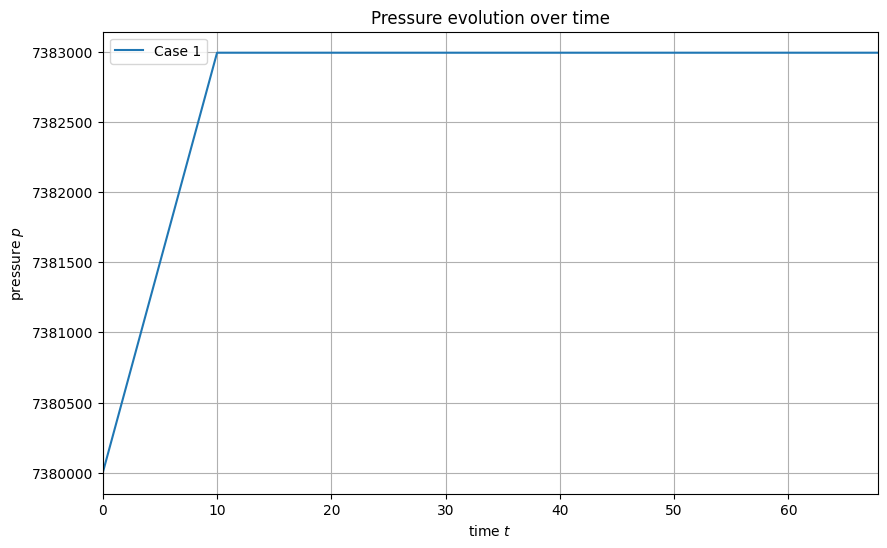

In [69]:
#pressure vs time

x_star = np.linspace(0, Lh, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_star_list[i])
    #time_record = np.arange(0, 1, Delta_t_star_list[i])
    time_record = np.linspace(0,tau_diff_list[i],num_steps_list[i]+1)
    plt.plot(time_record, p_all_cases[i], label=f'Case {i+1}')
zoom_time = 0.0001 * time_record[-1]  # Calculate 20% of the total time
plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star*tau_diff))], color='k', linestyle='--', label='t_heating')
plt.xlabel('time $t$')
plt.ylabel('pressure $p$')
plt.title('Pressure evolution over time')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

In [70]:
# #temperature vs time

# #x_star = np.linspace(0, Lh, Nx)

# plt.figure(figsize=(10, 6))
# for i in range(len(T0ic)):
#     #time_record = np.arange(0, tau_diff_list[i], Delta_t_star_list[i])
#     time_record = np.linspace(0,tau_diff_list[i],num_steps_list[i]+1)
#     plt.plot(time_record, T_all_cases[i][ : , int(Nx-1)  ]*Tc, label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
#     #plt.figure(figsize=(10, 6))
#     plt.plot( 0*Delta_t_star_list[i]*tau_diff_list[i],T_all_cases[i][ 0 , int(Nx-1)  ]*Tc, marker='x',markersize=5, color='black')
#     plt.plot( 10*Delta_t_star_list[i]*tau_diff_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] *Tc, marker='x',markersize=5, color='black')
#     plt.plot( num_steps_list[i]*Delta_t_star_list[i]*tau_diff_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] *Tc, marker='x',markersize=5, color='black')
# zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
# #plt.xlim(0, zoom_time)
# #plt.axvline(x=time_record[int(t_heating/(Delta_t_star*tau_diff))], color='k', linestyle='--', label='t_heating')
# plt.xlabel('Dimensionless time $t^*$')
# plt.ylabel('Dimensionless temperature $T^*$')
# plt.title('Temperature evolution over time')
# plt.legend()
# #plt.ylim(bottom=1.00286, top=1.00296)
# plt.grid(True)
# plt.ticklabel_format(style='plain', useOffset=False, axis='y')
# plt.ticklabel_format(style='plain', useOffset=False, axis='x')
# plt.show()

A fenti diagram alapján meg lehet határozni, hogy 

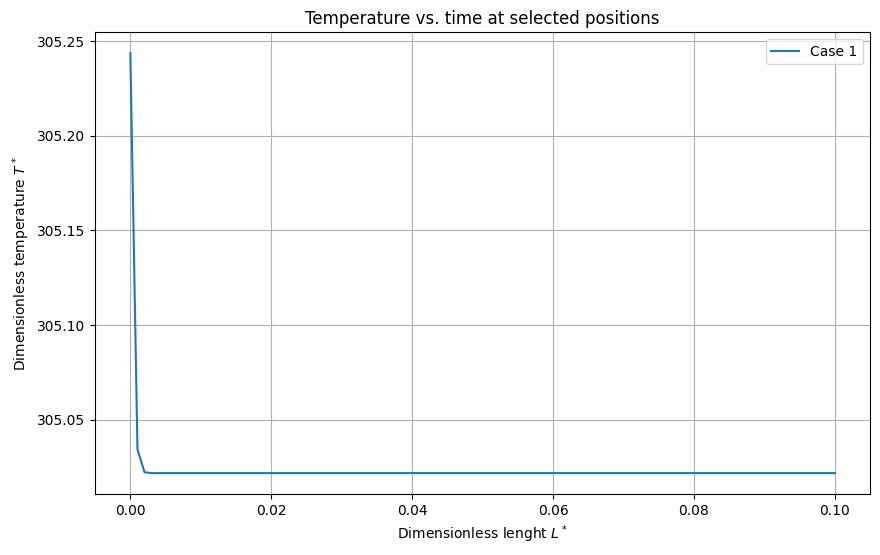

In [71]:
# temperature vs space

#x_star = np.linspace(0, Lh, Nx)
plt.figure(figsize=(10, 6))

for i in range(len(T0ic)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_star_list[i])
    plt.plot(x_star, T_all_cases[i][ 9 ,:  ], label=f'Case {i+1}')
#plt.plot(x_star, T_star[4, :], label='j = 4')
#plt.plot(x_star, T_star[9, :], label='j = 9')
#plt.plot(x_star, T_star[int(num_steps*0.01), :], label=f'j = {int(num_steps*0.01)}')
#plt.plot(x_star, T_star[int(num_steps*0.1), :], label=f'j = {int(num_steps*0.1)}')
#plt.plot(x_star, T_star[int(num_steps*0.5), :], label=f'j = {int(num_steps*0.5)}')
#plt.plot(x_star, T_star[int(num_steps*0.9), :], label=f'j = {int(num_steps*0.9)}')

#plt.ylim(bottom=1.05, top=1.058)
plt.xlabel('Dimensionless lenght $L^*$')
plt.ylabel('Dimensionless temperature $T^*$')
plt.title('Temperature vs. time at selected positions')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.show()

Dimenziós plotolás

In [72]:

print(num_steps_list)
print(tau_diff_list)


[678208]
[np.float64(678208.1839310066)]


In [73]:
spec_date = str(2025) + '-' +  str(12) + '-' +str(2)+ str(0)
print(spec_date)

2025-12-20


Itt elmentem a lineáris szimuláció adatait

In [74]:
import os
import json
import numpy as np
from datetime import date

today_str = date.today().isoformat() 
folder = "linear_results_" + spec_date# today_str #
os.makedirs(folder, exist_ok=True)

lists_to_save = {
    "num_steps_list_lin": num_steps_list,
    "tau_diff_list_lin": tau_diff_list,
    "T_all_cases_lin": T_all_cases,
    "p_all_cases_lin": p_all_cases,
    "Delta_t_star_list_lin":Delta_t_star_list,
    "beta_p0_list_lin":beta_p0_list,
    "chi_T0_list_lin":chi_T0_list,
    "t_heating_star_list_lin":t_heating_star_list,
}

def to_serializable(obj):
    """Recursively convert numpy objects to Python built-ins."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_serializable(v) for v in obj]
    else:
        return obj
    
for name, data in lists_to_save.items():
    safe_data = to_serializable(data)

    filename = os.path.join(folder, f"{name}.json")
    with open(filename, "w") as f:
        json.dump(safe_data, f)
    print(f"Saved {name} -> {filename}")


Saved num_steps_list_lin -> linear_results_2025-12-20\num_steps_list_lin.json
Saved tau_diff_list_lin -> linear_results_2025-12-20\tau_diff_list_lin.json
Saved T_all_cases_lin -> linear_results_2025-12-20\T_all_cases_lin.json
Saved p_all_cases_lin -> linear_results_2025-12-20\p_all_cases_lin.json
Saved Delta_t_star_list_lin -> linear_results_2025-12-20\Delta_t_star_list_lin.json
Saved beta_p0_list_lin -> linear_results_2025-12-20\beta_p0_list_lin.json
Saved chi_T0_list_lin -> linear_results_2025-12-20\chi_T0_list_lin.json
Saved t_heating_star_list_lin -> linear_results_2025-12-20\t_heating_star_list_lin.json
